Import the necessary python packages and libraries in the following cell.

In [ ]:
## Import the libraries here in this cell
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet18
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import seaborn as sns

Print the torch and torchvision version

In [ ]:
print(torch.__version__)
print(torchvision.__version__)

2.1.0+cu121
0.16.0+cu121


Set the device to cuda if available

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

Transform or preprocess the data utilizing the following operations.

*   Normalize data
*   Resize each image to 224 x 224
*   Add Color Jitter with hue and saturation as 0.5
*   Introduce Random horizontal flips
*   Rotate images about 20 degrees


In [ ]:
transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ColorJitter(hue=0.05, saturation=0.05),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(20),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
    ]
)

Select Even numbered Class labels in CIFAR10 Dataset.


**Overview of Subset class:** https://pytorch.org/docs/stable/_modules/torch/utils/data/dataset.html#Subset

In [ ]:
trainset = datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
testset = datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

even_classes = [i for i in range(0, 10, 2)]
# Select the indices that have even numbered labels
train_indices = [i for i, label in enumerate(trainset.targets) if label in even_classes]
test_indices = [i for i, label in enumerate(testset.targets) if label in even_classes]

# Define Subset with the selected indices
trainset = Subset(trainset, train_indices)
testset = Subset(testset, test_indices)

100%|██████████| 170498071/170498071 [00:01<00:00, 104416852.40it/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [ ]:
label_mapping = {label: idx for idx, label in enumerate(even_classes)}
print(label_mapping)
# FC layer of the model has output dimension of 5 Nodes [0, 1, 2, 3, 4].
# You are required to change the class numbers
# You'll get an out of bounds error or CUDA error if label mapping step is skipped.

# Before Label Mapping
print(trainset.dataset.targets)


trainset.dataset.targets = [
    label_mapping.get(label, label) for label in trainset.dataset.targets
]

# After Label Mapping
print(trainset.dataset.targets)

testset.dataset.targets = [
    label_mapping.get(label, label) for label in testset.dataset.targets
]

{0: 0, 2: 1, 4: 2, 6: 3, 8: 4}
[6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6, 4, 3, 6, 6, 2, 6, 3, 5, 4, 0, 0, 9, 1, 3, 4, 0, 3, 7, 3, 3, 5, 2, 2, 7, 1, 1, 1, 2, 2, 0, 9, 5, 7, 9, 2, 2, 5, 2, 4, 3, 1, 1, 8, 2, 1, 1, 4, 9, 7, 8, 5, 9, 6, 7, 3, 1, 9, 0, 3, 1, 3, 5, 4, 5, 7, 7, 4, 7, 9, 4, 2, 3, 8, 0, 1, 6, 1, 1, 4, 1, 8, 3, 9, 6, 6, 1, 8, 5, 2, 9, 9, 8, 1, 7, 7, 0, 0, 6, 9, 1, 2, 2, 9, 2, 6, 6, 1, 9, 5, 0, 4, 7, 6, 7, 1, 8, 1, 1, 2, 8, 1, 3, 3, 6, 2, 4, 9, 9, 5, 4, 3, 6, 7, 4, 6, 8, 5, 5, 4, 3, 1, 8, 4, 7, 6, 0, 9, 5, 1, 3, 8, 2, 7, 5, 3, 4, 1, 5, 7, 0, 4, 7, 5, 5, 1, 0, 9, 6, 9, 0, 8, 7, 8, 8, 2, 5, 2, 3, 5, 0, 6, 1, 9, 3, 6, 9, 1, 3, 9, 6, 6, 7, 1, 0, 9, 5, 8, 5, 2, 9, 0, 8, 8, 0, 6, 9, 1, 1, 6, 3, 7, 6, 6, 0, 6, 6, 1, 7, 1, 5, 8, 3, 6, 6, 8, 6, 8, 4, 6, 6, 1, 3, 8, 3, 4, 1, 7, 1, 3, 8, 5, 1, 1, 4, 0, 9, 3, 7, 4, 9, 9, 2, 4, 9, 9, 1, 0, 5, 9, 0, 8, 2, 1, 2, 0, 5, 6, 3, 2, 7, 8, 8, 6, 0, 7, 9, 4, 5, 6, 4, 2, 1, 1, 2, 1, 5, 9, 9, 0, 8, 4, 1, 1, 6, 3, 3, 9, 0, 7, 9, 7, 7, 9,

In [ ]:
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [ ]:
model = resnet18(weights="DEFAULT").to(device)
model.fc = nn.Linear(model.fc.in_features, len(even_classes)).to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 135MB/s]


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Complete the code for backpropagation inside the train function.



In [ ]:
def train(model, trainloader, criterion, optimizer, device):

    model.train()

    train_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, pred = outputs.max(1)
        total_train += labels.size(0)
        correct_train += pred.eq(labels).sum().item()

    train_acc = 100 * correct_train / total_train

    return train_loss / len(trainloader), train_acc

Complete the test function to test out the model.

In [ ]:
def test(model, testloader, criterion, device):
    model.eval()
    correct_test = 0
    total_test = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total_test += labels.size(0)
            correct_test += predicted.eq(labels).sum().item()

    test_accuracy = 100 * correct_test / total_test
    return test_accuracy

Accuracies plot function

In [ ]:
def plot_accuracies(train_accuracies, test_accuracies, epochs):

    plt.plot(range(1, epochs + 1), train_accuracies, label="Train Accuracy")
    plt.plot(range(1, epochs + 1), test_accuracies, label="Test Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Train and Test Accuracies vs Epochs")
    plt.legend()
    plt.show()

Confusion Matrix (without sklearn)

In [ ]:
def plot_confusion_matrix(model, dataloader, class_names, device):
    model.eval()
    all_labels = []
    all_predictions = []

    num_classes = len(class_names)
    confusion_matrix = torch.zeros(num_classes, num_classes)

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, pred = outputs.max(1)

            for t, p in zip(labels.view(-1), pred.view(-1)):
                confusion_matrix[t.long(), p.long()] += 1

    plt.figure(figsize=(num_classes, num_classes))
    sns.heatmap(
        confusion_matrix,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Main loop

Epoch 1 | Train Loss: 0.395 | Train Accuracy: 85.684% | Test Accuracy: 86.980%
Epoch 2 | Train Loss: 0.239 | Train Accuracy: 91.452% | Test Accuracy: 87.800%
Epoch 3 | Train Loss: 0.192 | Train Accuracy: 93.044% | Test Accuracy: 89.600%
Epoch 4 | Train Loss: 0.167 | Train Accuracy: 94.016% | Test Accuracy: 92.000%
Epoch 5 | Train Loss: 0.137 | Train Accuracy: 95.108% | Test Accuracy: 92.720%


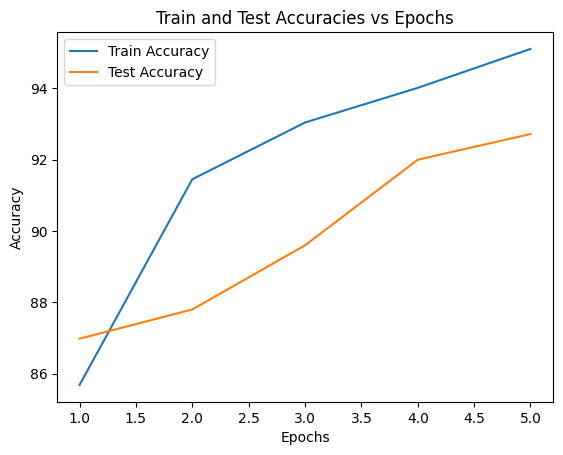

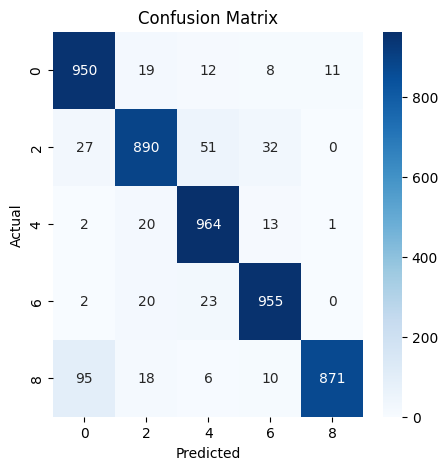

In [ ]:
epochs = 5
train_accuracies = []
test_accuracies = []

for epoch in range(epochs):
    train_loss, train_acc = train(model, trainloader, criterion, optimizer, device)
    test_acc = test(model, testloader, criterion, device)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(
        f"Epoch {epoch + 1} | Train Loss: {train_loss:.3f} | Train Accuracy: {train_acc:.3f}% | Test Accuracy: {test_acc:.3f}%"
    )


plot_accuracies(train_accuracies, test_accuracies, epochs)
class_names = ["0", "2", "4", "6", "8"]
plot_confusion_matrix(model, testloader, class_names, device)